Data preprocessing


---


*   Lower case
*   Tokenization
*   Removing special characters
*   Removing stop words(is, of) and punctuation
*   Stemming( Dancing Dances to Dance)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
!pip install nltk
import nltk                # Natural Language Toolkit, a library for natural language processing tasks.
nltk.download("punkt_tab") # Download the punkt tokenizer models for tokenizing text into sentences and words.
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\Notes\ML\Project\data\processed\cleaned_data.csv") # Load the cleaned dataset from the specified path using pandas' read_csv function. The dataset is expected to be in CSV format and is located in the "processed" folder within the "data" directory of the project.
df.head() # Display the first few rows of the dataset to verify that it has been loaded

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [30]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english")) # Create a set of English stop words using the stopwords corpus from NLTK. Stop words are common words that are often removed from text data during preprocessing because they do not carry significant meaning (e.g., "the", "is", "in", etc.). The set data structure is used for efficient membership testing when removing stop words from the text.   

import string
string.punctuation # Access the string module's punctuation attribute, which contains a string of all punctuation characters. This can be used to remove punctuation from text data during preprocessing.

ps = PorterStemmer() # Create an instance of the PorterStemmer class from NLTK. The Porter Stemmer is a popular algorithm for stemming words, which reduces words to their base or root form (e.g., "running" becomes "run"). This can help in reducing the dimensionality of the text data and improving the performance of machine learning models.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
def data_preprocessing(text):
    """This function takes a text input and performs several preprocessing steps to clean and prepare the text for further analysis or modeling. 
       The steps include converting the text to lowercase, tokenizing the text into words, removing non-alphanumeric tokens, removing stop words and 
       punctuation, and applying stemming to reduce words to their base form. 
       Finally, the cleaned tokens are joined back into a single string and returned as output.
    Args:        text (str): The input text that needs to be preprocessed.
    Returns:        str: The preprocessed and cleaned text after applying all the steps.
    """
    text = text.lower() 
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [40]:
df['transformed_text'] = df['text'].apply(data_preprocessing) # Apply the data_preprocessing function to the 'text' column of the DataFrame. This will clean and preprocess the text data in that column according to the steps defined in the function.
df.head() # Display the first few rows of the DataFrame to verify that the text preprocessing has been applied correctly.

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,go jurong point crazi avail bugi n great world...,111,24,2,go jurong point crazi avail bugi n great world...
1,0,ok lar joke wif u oni,29,8,2,ok lar joke wif u oni
2,1,free entri 2 wkli comp win fa cup final tkt 21...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say earli hor u c alreadi say,49,13,1,u dun say earli hor u c alreadi say
4,0,nah think goe usf live around though,61,15,1,nah think goe usf live around though


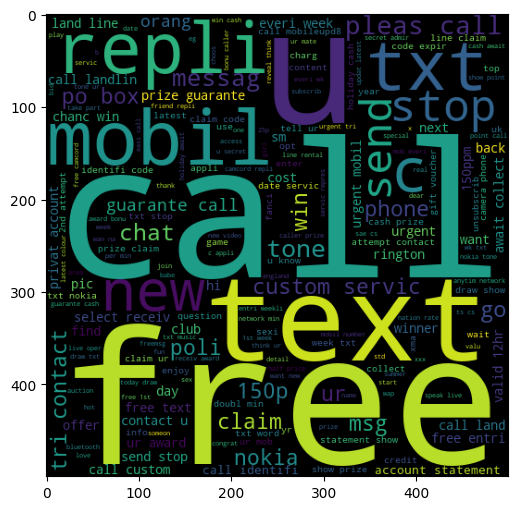

In [42]:
from wordcloud import WordCloud
spam_wordcloud = WordCloud(width = 500, height = 500).generate(df[df['target'] == 1]['text'].str.cat(sep = " ")) # Generate a word cloud for the spam messages in the dataset. The WordCloud class from the wordcloud library is used to create a word cloud visualization. The width and height parameters specify the dimensions of the word cloud image. The generate method takes a string input, which is created by concatenating all the text from the 'text' column of the DataFrame where the 'target' column is equal to 1 (indicating spam messages). The str.cat method is used to concatenate the text with a space separator.
plt.figure(figsize = (15, 6)) # Set the figure size for the plot to 15 inches in width and 6 inches in height.
plt.imshow(spam_wordcloud) # Display the generated word cloud image using the imshow function from matplotlib.

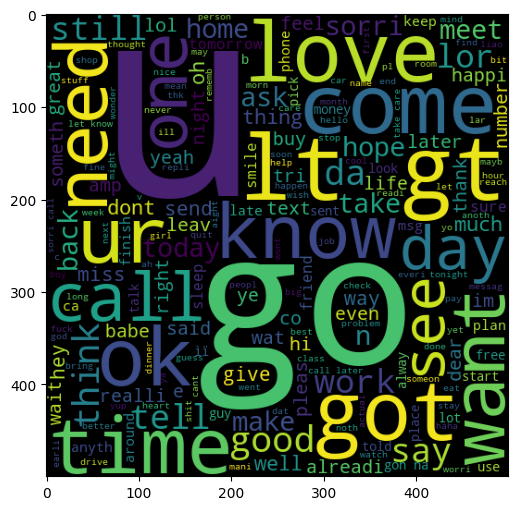

In [43]:
from wordcloud import WordCloud
ham_wordcloud = WordCloud(width = 500, height = 500).generate(df[df['target'] == 0]['text'].str.cat(sep = " ")) # Generate a word cloud for the non-spam messages in the dataset. The WordCloud class from the wordcloud library is used to create a word cloud visualization. The width and height parameters specify the dimensions of the word cloud image. The generate method takes a string input, which is created by concatenating all the text from the 'text' column of the DataFrame where the 'target' column is equal to 0 (indicating non-spam messages). The str.cat method is used to concatenate the text with a space separator.
plt.figure(figsize = (15, 6)) # Set the figure size for the plot to 15 inches in width and 6 inches in height.
plt.imshow(ham_wordcloud) # Display the generated word cloud image using the imshow function from matplotlib.

In [44]:
# Export preprocessed dataset for the text preprocessing stage

df.to_csv(
    "../data/processed/preprocessed_data.csv",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


In [45]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [46]:
len(spam_corpus)

11481

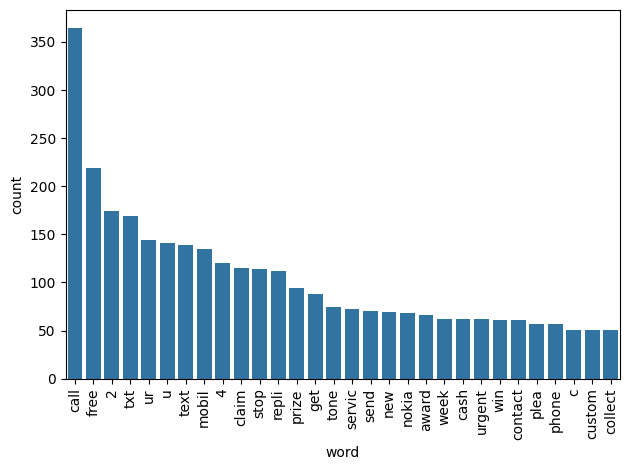

In [ ]:
from collections import Counter
""" The Counter class from the collections module is used to count the frequency of each word in the spam_corpus list. 
The most_common(30) method is called on the Counter object to retrieve the 30 most common words along with their counts. 
The resulting list of tuples (word, count) is then converted into a pandas DataFrame with columns "word" and "count". 
This DataFrame is used to create a bar plot using seaborn's barplot function, where the x-axis represents the words and 
the y-axis represents their corresponding counts. The x-ticks are rotated by 90 degrees for better readability, and 
tight_layout is called to adjust the layout of the plot.
"""
spam_freq = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=["word", "count"])
sns.barplot(x="word", y="count", data=spam_freq)
plt.xticks(rotation=90)
plt.tight_layout()

In [56]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [58]:
len(ham_corpus)

38100

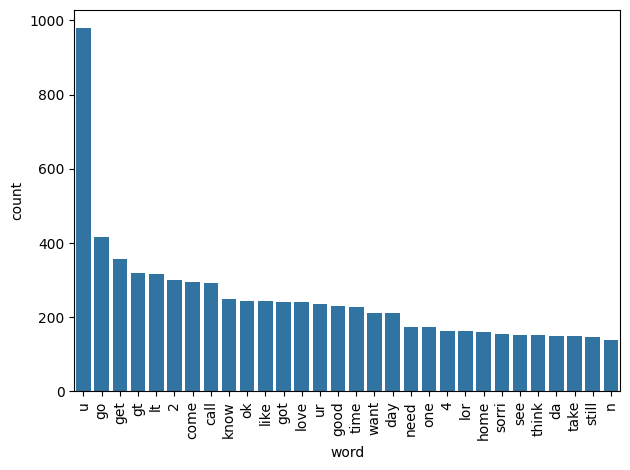

In [ ]:
from collections import Counter
""" The Counter class from the collections module is used to count the frequency of each word in the ham_corpus list. 
The most_common(30) method is called on the Counter object to retrieve the 30 most common words along with their counts. 
The resulting list of tuples (word, count) is then converted into a pandas DataFrame with columns "word" and "count". 
This DataFrame is used to create a bar plot using seaborn's barplot function, where the x-axis represents the words and 
the y-axis represents their corresponding counts. The x-ticks are rotated by 90 degrees for better readability, and 
tight_layout is called to adjust the layout of the plot.
"""
ham_freq = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=["word", "count"])
sns.barplot(x="word", y="count", data=ham_freq)
plt.xticks(rotation=90)
plt.tight_layout()